In [10]:
# ATIVIDADE DIRIGIDA 2 — Regressão Linear Múltipla SaaS

# Instalações
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

In [11]:
from google.colab import drive
drive.mount('/content/drive')

# Ajuste o caminho se necessário
df = pd.read_csv('/content/drive/MyDrive/dataset_saas.csv')

print("Shape:", df.shape)
print("\nPrimeiras linhas:")
display(df.head())
print("\nInfo:")
df.info()
print("\nEstatísticas descritivas:")
display(df.describe())

df_model = df.copy()

# tipo_conta: corporativo=1, individual=0
le = LabelEncoder()
df_model['tipo_conta_enc'] = le.fit_transform(df_model['tipo_conta'])

# regiao_cluster: encoding dummies
df_model = pd.get_dummies(df_model, columns=['regiao_cluster'], drop_first=True)

# pico_noturno: garante que seja 0/1
df_model['pico_noturno'] = df_model['pico_noturno'].map({'sim': 1, 'nao': 0}).astype(int)

print("\nColunas após pré-processamento:")
print(df_model.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (1338, 7)

Primeiras linhas:


,tempo_operacao_meses,tipo_conta,carga_media_diaria_horas,num_integracoes,pico_noturno,regiao_cluster,custo_mensal_infra
0,19,individual,8.7,0,sim,cluster_oeste,4947.78
1,18,corporativa,10.6,1,nao,cluster_sudeste,703.15
2,28,corporativa,10.3,3,nao,cluster_sudeste,1465.85
3,33,corporativa,7.1,0,nao,cluster_noroeste,6375.65
4,32,corporativa,9.0,0,nao,cluster_noroeste,1302.72



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tempo_operacao_meses      1338 non-null   int64  
 1   tipo_conta                1338 non-null   object 
 2   carga_media_diaria_horas  1338 non-null   float64
 3   num_integracoes           1338 non-null   int64  
 4   pico_noturno              1338 non-null   object 
 5   regiao_cluster            1338 non-null   object 
 6   custo_mensal_infra        1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Estatísticas descritivas:


,tempo_operacao_meses,carga_media_diaria_horas,num_integracoes,custo_mensal_infra
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,9.579821,1.094918,3935.718393
std,14.049960,1.905500,1.205493,3390.803212
min,18.000000,5.000000,0.000000,534.120000
25%,27.000000,8.200000,0.000000,1547.285000
50%,39.000000,9.500000,1.000000,2846.970000
75%,51.000000,10.800000,2.000000,4879.175000
max,64.000000,16.600000,5.000000,18075.720000



Colunas após pré-processamento:
['tempo_operacao_meses', 'tipo_conta', 'carga_media_diaria_horas', 'num_integracoes', 'pico_noturno', 'custo_mensal_infra', 'tipo_conta_enc', 'regiao_cluster_cluster_noroeste', 'regiao_cluster_cluster_oeste', 'regiao_cluster_cluster_sudeste']


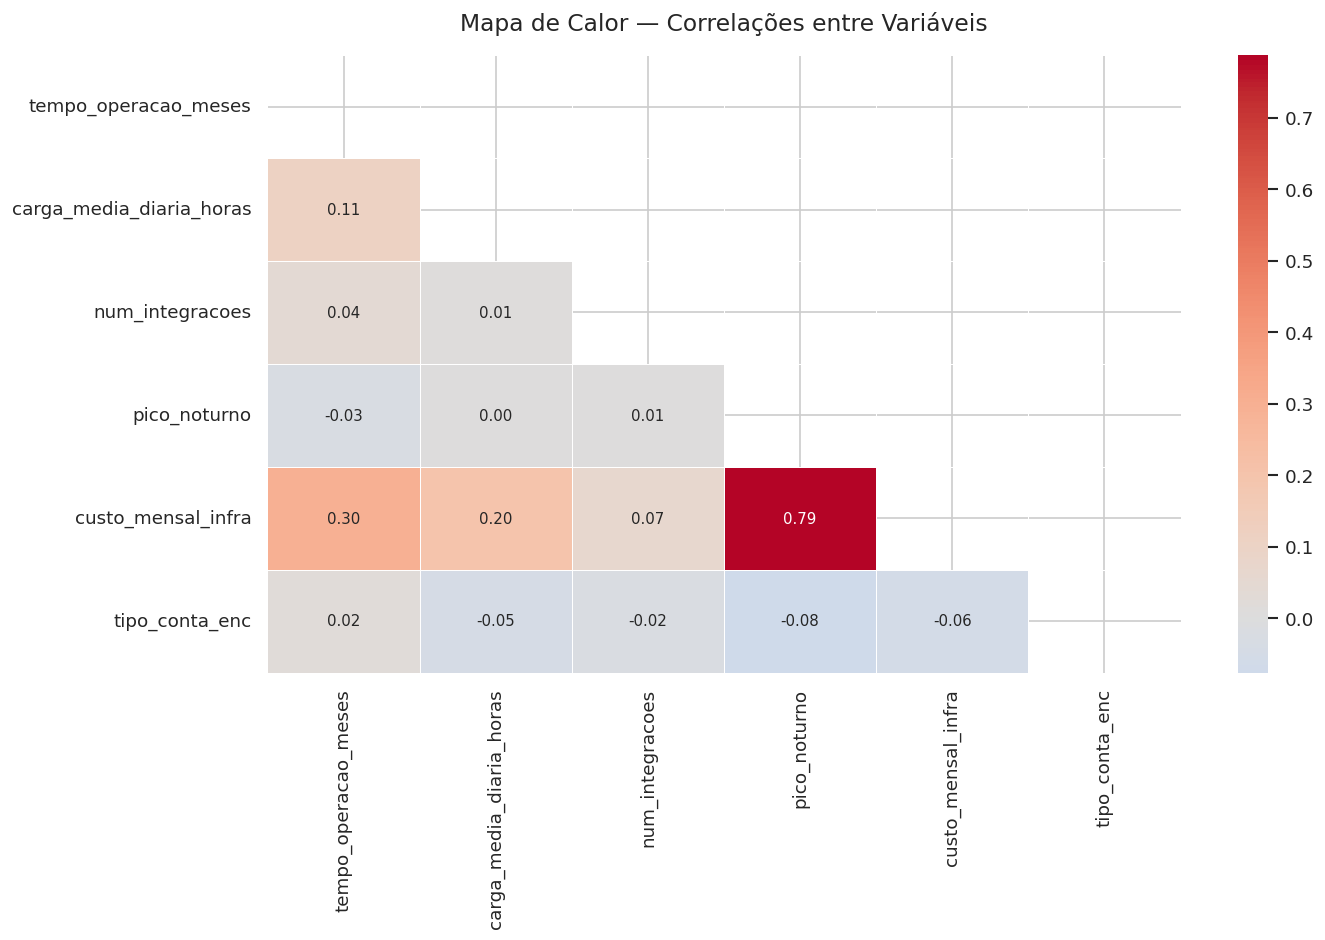


Correlação com custo_mensal_infra:
pico_noturno                0.787251
tempo_operacao_meses        0.299008
carga_media_diaria_horas    0.198133
num_integracoes             0.067998
tipo_conta_enc             -0.057292
Name: custo_mensal_infra, dtype: float64


In [6]:
# Seleciona apenas colunas numéricas
numericas = df_model.select_dtypes(include=[np.number])

corr_matrix = numericas.corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # só triângulo inferior
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title('Mapa de Calor — Correlações entre Variáveis', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Correlações com a variável alvo
print("\nCorrelação com custo_mensal_infra:")
corr_target = corr_matrix['custo_mensal_infra'].drop('custo_mensal_infra').sort_values(ascending=False)
print(corr_target)

Top 2 variáveis mais correlacionadas: ['pico_noturno', 'tempo_operacao_meses']

Modelo 1 (1 variável)
  Features: ['pico_noturno']
  R²:   0.6602
  RMSE: 2033.54
  Coeficientes: {'pico_noturno': np.float64(6492.832)}
  Intercepto:   2621.93

Modelo 2 (2 variáveis)
  Features: ['pico_noturno', 'tempo_operacao_meses']
  R²:   0.7535
  RMSE: 1732.26
  Coeficientes: {'pico_noturno': np.float64(6632.809), 'tempo_operacao_meses': np.float64(77.283)}
  Intercepto:   -448.46

Modelo 3 (completo)
  Features: ['tempo_operacao_meses', 'carga_media_diaria_horas', 'num_integracoes', 'pico_noturno', 'tipo_conta_enc', 'regiao_cluster_cluster_noroeste', 'regiao_cluster_cluster_oeste', 'regiao_cluster_cluster_sudeste']
  R²:   0.7834
  RMSE: 1623.51
  Coeficientes: {'tempo_operacao_meses': np.float64(71.964), 'carga_media_diaria_horas': np.float64(302.123), 'num_integracoes': np.float64(119.187), 'pico_noturno': np.float64(6622.306), 'tipo_conta_enc': np.float64(4.927), 'regiao_cluster_cluster_noroeste

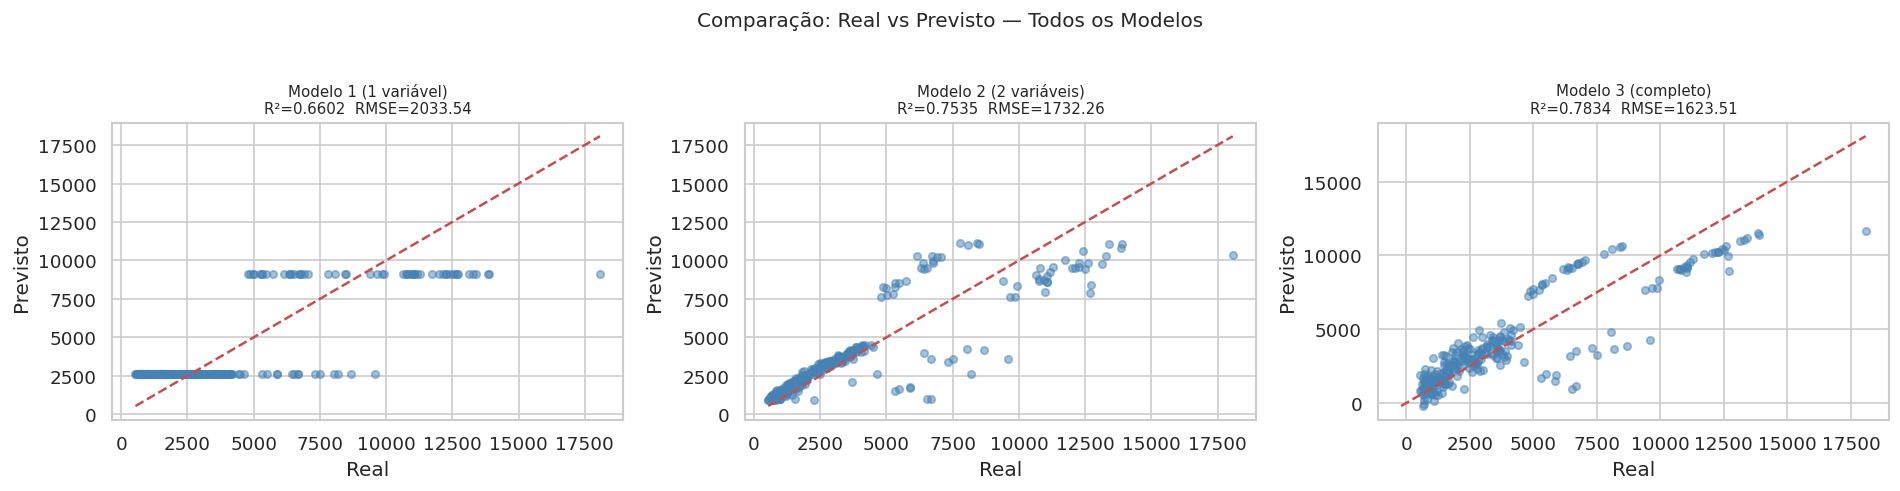


--- Resumo Comparativo ---


,R²,RMSE
Modelo 1 (1 variável),0.6602,2033.54
Modelo 2 (2 variáveis),0.7535,1732.26
Modelo 3 (completo),0.7834,1623.51


In [7]:
TARGET = 'custo_mensal_infra'

# Remove colunas originais categóricas não codificadas
cols_excluir = ['tipo_conta', TARGET]
if 'regiao_cluster' in df_model.columns:
    cols_excluir.append('regiao_cluster')

feature_cols = [c for c in df_model.columns if c not in cols_excluir]

# ------ Selecionar as 2 variáveis mais correlacionadas ------
top2 = corr_target.abs().nlargest(2).index.tolist()
print(f"Top 2 variáveis mais correlacionadas: {top2}")

# ------ Definição dos modelos ------
modelos = {
    'Modelo 1 (1 variável)' : [top2[0]],
    'Modelo 2 (2 variáveis)': top2,
    'Modelo 3 (completo)'   : feature_cols
}

resultados = {}

for nome, features in modelos.items():
    X = df_model[features]
    y = df_model[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    reg = LinearRegression()
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    resultados[nome] = {
        'Features'  : features,
        'R²'        : round(r2, 4),
        'RMSE'      : round(rmse, 2),
        'Modelo'    : reg,
        'X_test'    : X_test,
        'y_test'    : y_test,
        'y_pred'    : y_pred
    }
    print(f"\n{nome}")
    print(f"  Features: {features}")
    print(f"  R²:   {r2:.4f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  Coeficientes: {dict(zip(features, reg.coef_.round(3)))}")
    print(f"  Intercepto:   {reg.intercept_:.2f}")

# ------ Comparação visual ------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nome, res) in zip(axes, resultados.items()):
    ax.scatter(res['y_test'], res['y_pred'], alpha=0.5, s=20, color='steelblue')
    lims = [min(res['y_test'].min(), res['y_pred'].min()),
            max(res['y_test'].max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_title(f"{nome}\nR²={res['R²']}  RMSE={res['RMSE']}", fontsize=9)
    ax.set_xlabel("Real")
    ax.set_ylabel("Previsto")

plt.suptitle("Comparação: Real vs Previsto — Todos os Modelos", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ------ Tabela resumo ------
resumo = pd.DataFrame({k: {'R²': v['R²'], 'RMSE': v['RMSE']} for k, v in resultados.items()}).T
print("\n--- Resumo Comparativo ---")
display(resumo)

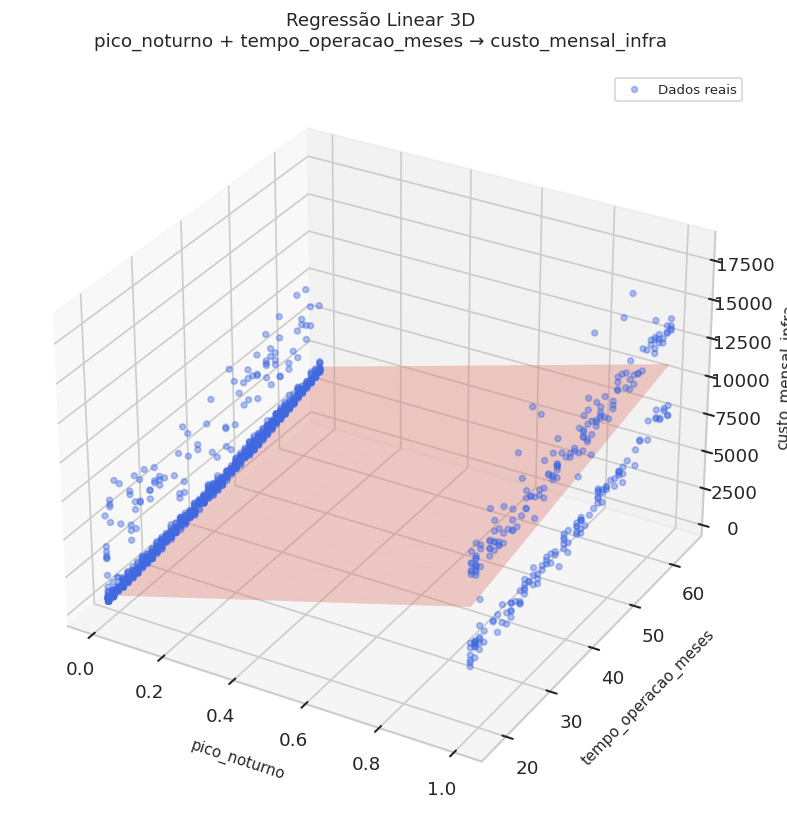


Equação do modelo 3D:
  custo_mensal_infra = -449.66 + 6679.4857·pico_noturno + 76.9639·tempo_operacao_meses


In [8]:
var1, var2 = top2[0], top2[1]

X2 = df_model[[var1, var2]]
y  = df_model[TARGET]

reg2 = LinearRegression()
reg2.fit(X2, y)

# Cria grade para o plano de regressão
v1_range = np.linspace(X2[var1].min(), X2[var1].max(), 30)
v2_range = np.linspace(X2[var2].min(), X2[var2].max(), 30)
V1, V2 = np.meshgrid(v1_range, v2_range)

Z = reg2.intercept_ + reg2.coef_[0] * V1 + reg2.coef_[1] * V2

fig = plt.figure(figsize=(11, 7))
ax  = fig.add_subplot(111, projection='3d')

# Pontos reais
ax.scatter(
    df_model[var1], df_model[var2], y,
    color='royalblue', alpha=0.4, s=12, label='Dados reais'
)

# Plano de regressão
ax.plot_surface(V1, V2, Z, alpha=0.35, color='salmon', edgecolor='none')

ax.set_xlabel(var1, fontsize=9, labelpad=8)
ax.set_ylabel(var2, fontsize=9, labelpad=8)
ax.set_zlabel(TARGET, fontsize=9, labelpad=8)
ax.set_title(
    f'Regressão Linear 3D\n{var1} + {var2} → {TARGET}',
    fontsize=11, pad=15
)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nEquação do modelo 3D:")
print(f"  custo_mensal_infra = {reg2.intercept_:.2f}"
      f" + {reg2.coef_[0]:.4f}·{var1}"
      f" + {reg2.coef_[1]:.4f}·{var2}")

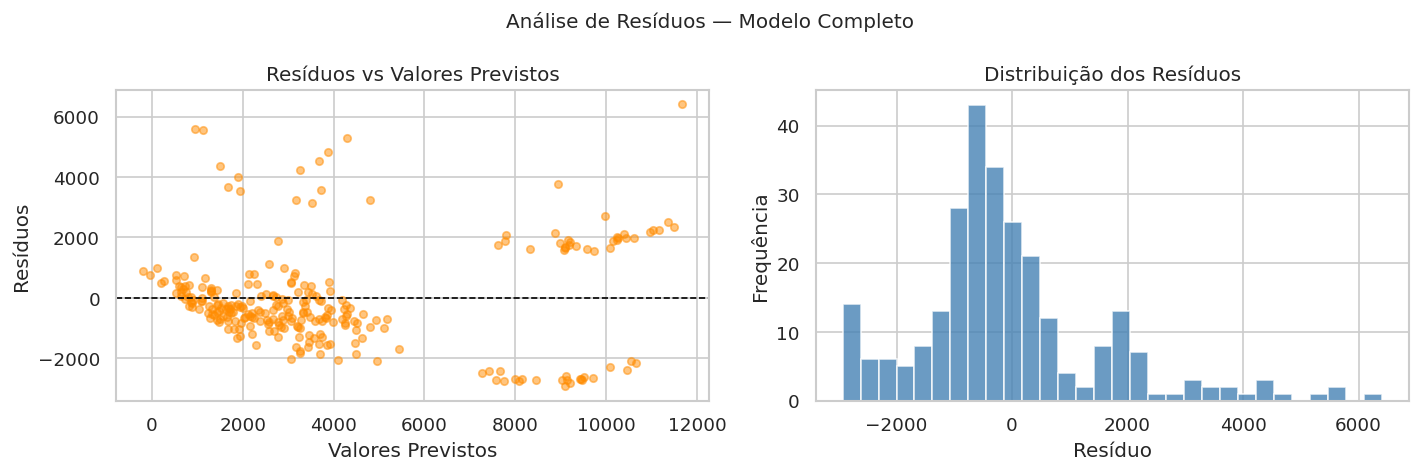

In [9]:
melhor = resultados['Modelo 3 (completo)']
residuos = melhor['y_test'] - melhor['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Resíduos vs Previsto
axes[0].scatter(melhor['y_pred'], residuos, alpha=0.5, s=20, color='darkorange')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel("Valores Previstos")
axes[0].set_ylabel("Resíduos")
axes[0].set_title("Resíduos vs Valores Previstos")

# Histograma dos resíduos
axes[1].hist(residuos, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel("Resíduo")
axes[1].set_ylabel("Frequência")
axes[1].set_title("Distribuição dos Resíduos")

plt.suptitle("Análise de Resíduos — Modelo Completo", fontsize=12)
plt.tight_layout()
plt.show()